In [1]:
!hpc-ticket
!hpc-mount wissdaten

ERROR: target folder is already mounted somewhere


# Running

In [1]:
from src.utils import get_data_env
from src.dataloading.epidataorchestration import EpiConfig, EpiDataOrchestrator
from src.dataloading import DeepDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager

# get data
# disease_name    = 'influenza'
# nuts_level      = 'nuts3'
# min_date        = '2011-06-01'
# max_date        = '2020-06-01'
# split_trainval  = '2018-06-01'
# split_valtest   = '2019-06-01'
# split_berlin    = False

# horizon_size    = 1
# horizon_leadtime= 3
# sequence_length = 10
# lag_num         = 1

disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    temporal_frequency  = 'd',
    time_index_d        = True,
    time_index_w        = False, 
    feature_population_size=False,

    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

epidataorchestrator = EpiDataOrchestrator(config).build()
bldata = BaseLineDataLoaderManager(epidataorchestrator)

dlm = DeepDataLoaderManager(epidataorchestrator)
dlm.build()

glm = GraphDataLoaderManager(epidataorchestrator).retrieve_static_graph('identity_graph')
glm.build()

glm2 = GraphDataLoaderManager(epidataorchestrator).retrieve_static_graph('geographical_neighbors1')
glm2.build()

<GraphDataLoaderManager(dataloaders at .dataloader_main, .dataloader_train, .dataloader_val, .dataloader_test)>

In [5]:
epidataorchestrator.data_final.data_denorm

,timestamp,nuts_node,target_lead7,tt_sin_d,tt_cos_d,incidence_lag0,train,val,test
0,2020-03-02,0,0.000000,0.781831,0.62349,0.000000,True,False,False
1,2020-03-02,1,0.000000,0.781831,0.62349,0.000000,True,False,False
2,2020-03-02,2,0.000000,0.781831,0.62349,0.000000,True,False,False
3,2020-03-02,3,0.000000,0.781831,0.62349,0.000000,True,False,False
4,2020-03-02,4,0.000000,0.781831,0.62349,0.000000,True,False,False
...,...,...,...,...,...,...,...,...,...
411595,2022-12-25,395,0.000000,-0.0,1.0,0.000000,False,False,True
411596,2022-12-25,396,1.196244,-0.0,1.0,0.484772,False,False,True
411597,2022-12-25,397,0.000000,-0.0,1.0,0.253068,False,False,True
411598,2022-12-25,398,0.944574,-0.0,1.0,0.104056,False,False,True


# Models

In [3]:
from src.models import PersistenceModel 
from src.models.deepv2.architectures.lstm import LSTMModel
from src.models.deepv2.architectures.gatv2lstm import GATv2LSTMModel

ps = PersistenceModel(bldata)
ps.forecast('test')

PersistenceModel(name='persistence_model')

# LSTM

Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.2469

==                      id                      ==
model_hparams_set ✓
✓ Debugging went fine
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.1553, val loss: 0.6835 ✓ (new best)
Epoch 002 train loss: 0.1392, val loss: 0.6598 ✓ (new best)
Epoch 003 train loss: 0.1288, val loss: 0.6393 ✓ (new best)
Epoch 004 train loss: 0.1259, val loss: 0.6303 ✓ (new best)
Epoch 005 train loss: 0.1250, val loss: 0.5813 ✓ (new best)
Epoch 006 train loss: 0.1258, val loss: 0.5659 ✓ (new best)
Epoch 007 train loss: 0.1266, val loss: 0.5346 ✓ (new best)
Epoch 008 train loss: 0.1280, val loss: 0.5159 ✓ (new best)
Epoch 009 train loss: 0.1306, val loss: 0.4966 ✓ (new best)
Epoch 010 train loss: 0.1314, val loss: 0.4664 ✓ (new best)
Epoch 011 train loss: 0.1347, val loss: 0.4404 ✓ (new best)
Epoch 012 train

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deepv2/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 100 train loss: 0.1281, val loss: 0.2168 (patience: 5/15)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 523.55it/s]


Test loss: 0.2205
forecasted ✓

==                      gm                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.1718, val loss: 0.7137 ✓ (new best)
Epoch 002 train loss: 0.1396, val loss: 0.6641 ✓ (new best)
Epoch 003 train loss: 0.1285, val loss: 0.6257 ✓ (new best)
Epoch 004 train loss: 0.1259, val loss: 0.6061 ✓ (new best)
Epoch 005 train loss: 0.1259, val loss: 0.5761 ✓ (new best)
Epoch 006 train loss: 0.1254, val loss: 0.5793 (patience: 1/15)
Epoch 007 train loss: 0.1260, val loss: 0.5647 ✓ (new best)
Epoch 008 train loss: 0.1273, val loss: 0.5462 ✓ (new best)
Epoch 009 train loss: 0.1286, val loss: 0.5493 (patience: 1/15)
Epoch 010 train loss: 0.1317, val loss: 0.5041 ✓ (new best)
Epoch 011 train loss: 0.1341, val loss: 0.4637 ✓ (new best)
Epoch 012 train loss: 0.1372, val loss: 0.4279 ✓ (new best)
Epoch 013 train loss: 0.1401, val loss: 0.4131 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deepv2/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.2443
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 528.48it/s]

Test loss: 0.2381
forecasted ✓


GATv2LSTMModel(name='gm')

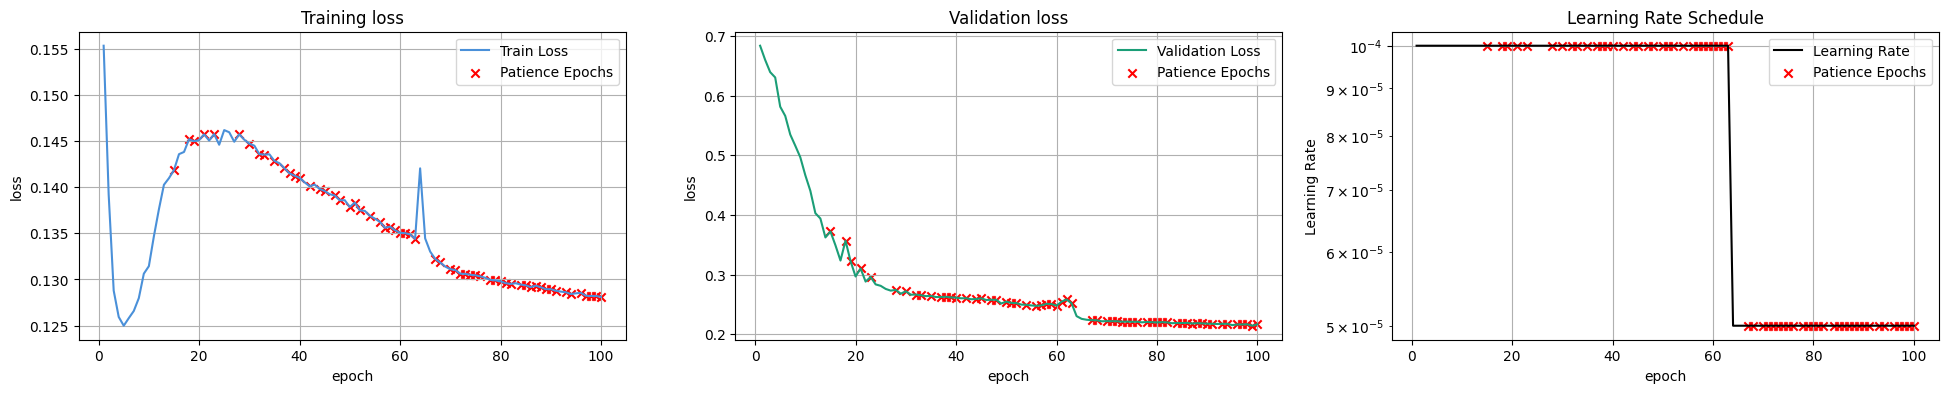

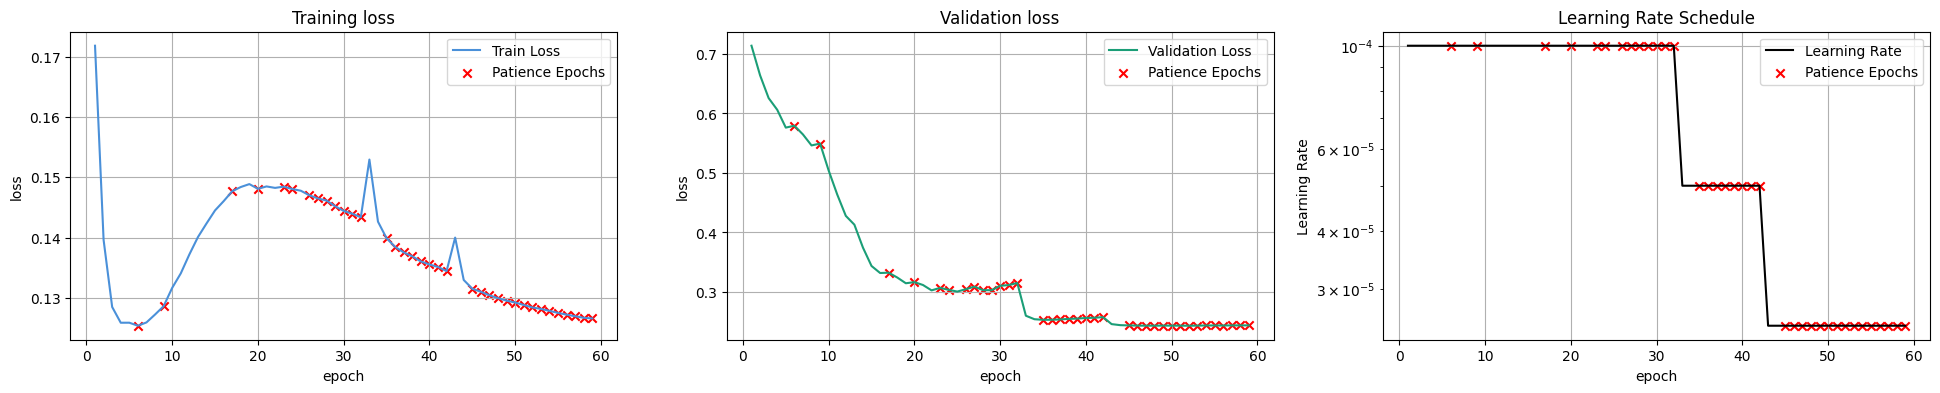

In [5]:
global_hparams = {
    'lr'    :   1e-4,
    'min_delta' : 0.001,
    'n_epochs': 100,
    'scheduler':'plateau',
    'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 6},
    }


lstm = LSTMModel(dlm)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast()
lstm.show_forecasts(26,dataset='test').show()

model_hparams = {
    'hidden_size': 128,        # Much larger LSTM
    'gat_hidden_dim': 32,      # Smaller GAT (less influence)
    'num_layers': 2,
    'num_heads': 2,            # Keep same
    'dropout': 0.3,            # Moderate dropout
    'temporal_layers': 2,      # If you have this parameter
}


ml1 = GATv2LSTMModel(glm, name = 'id', verbose = 2)
ml1.set_model_hparams(**model_hparams)
ml1.debug()
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast('test')


ml2 = GATv2LSTMModel(glm2, name = 'gm', verbose = 2)
ml2.set_model_hparams(**model_hparams)
ml2.set_global_hparams(**global_hparams)
ml2.train()
ml2.forecast('test')



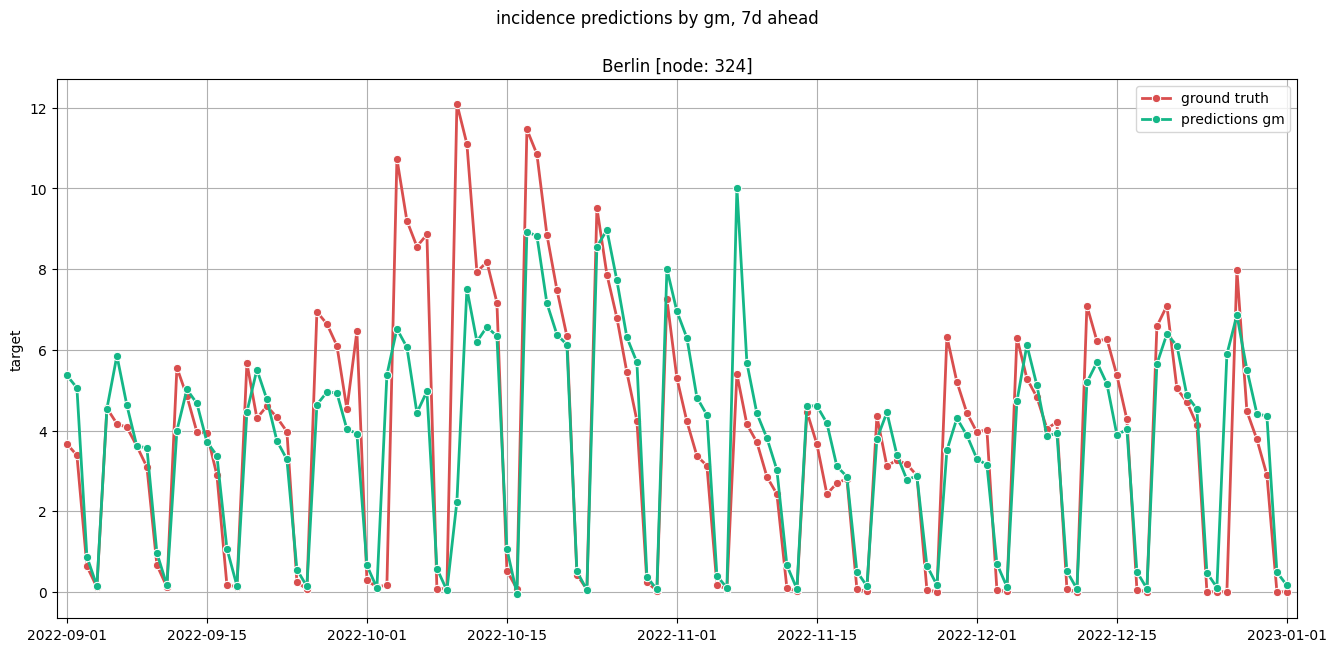

In [9]:
ml2.show_forecasts(324).show()

# GATV2

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.66it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


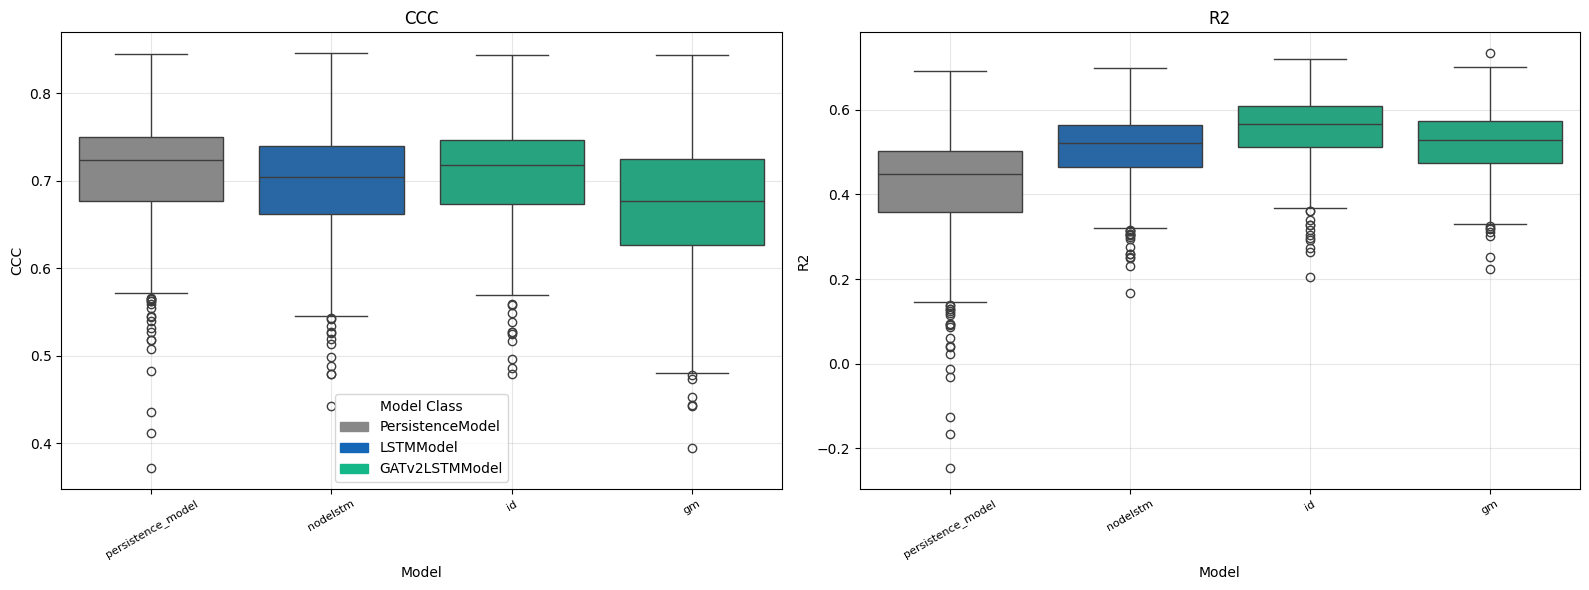

In [6]:
from src.evaluation import Evaluator 

e = Evaluator([ps, lstm, ml1, ml2]).add_evaluation()
e.plotter.plot_metric_compilation(metrics = ['ccc','r2']).show()

In [12]:
import numpy as np
def spatial_autocorrelation_of_errors(predictions_df, edge_index):
    """
    Moran's I for prediction errors
    Checks if errors are spatially clustered
    """
    import pandas as pd
    
    # Calculate errors per node
    errors_by_node = predictions_df.groupby('nuts_node')['pred'].apply(
        lambda x: (x - predictions_df.loc[x.index, 'target']).abs().mean()
    )
    
    # Moran's I calculation
    n = len(errors_by_node)
    y = errors_by_node.values
    y_mean = y.mean()
    
    # Build adjacency matrix from edge_index
    W = np.zeros((n, n))
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[:, i]
        W[src, dst] = 1
    
    # Row normalize
    W = W / W.sum(axis=1, keepdims=True)
    
    # Moran's I
    numerator = np.sum(W * np.outer(y - y_mean, y - y_mean))
    denominator = np.sum((y - y_mean) ** 2)
    morans_i = (n / W.sum()) * (numerator / denominator)
    
    return morans_i

# Use it
model = ml1

predictions = model.predictions.get_preds('test').get_original(0)
morans_i = spatial_autocorrelation_of_errors(
    predictions, 
    model.dataloadermanager.graph.edge_index
)
print(f"Moran's I for errors: {morans_i:.3f}")
print("(Positive = errors clustered, 0 = random, Negative = dispersed)")

Moran's I for errors: 1.000
(Positive = errors clustered, 0 = random, Negative = dispersed)
